# Explore & Clean Data

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import precision_score, recall_score, f1_score

sns.set_style('whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('german_credit_data.csv')
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [3]:
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [4]:
print(f'Shape: {df.shape}')
df.info()

Shape: (1000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB


In [5]:
df.describe() 

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [6]:
df.isnull().sum().sort_values(ascending=False)

Checking account    394
Saving accounts     183
Age                   0
Sex                   0
Job                   0
Housing               0
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [7]:
for col in ['Saving accounts', 'Checking account']:
    if col in df.columns:
        df[col] = df[col].fillna('none')

df.isnull().sum().sum()

0

In [8]:
print(f'Duplicate rows: {df.duplicated().sum()}')

Duplicate rows: 0


Risk
good    700
bad     300
Name: count, dtype: int64
Risk
good    0.7
bad     0.3
Name: proportion, dtype: float64


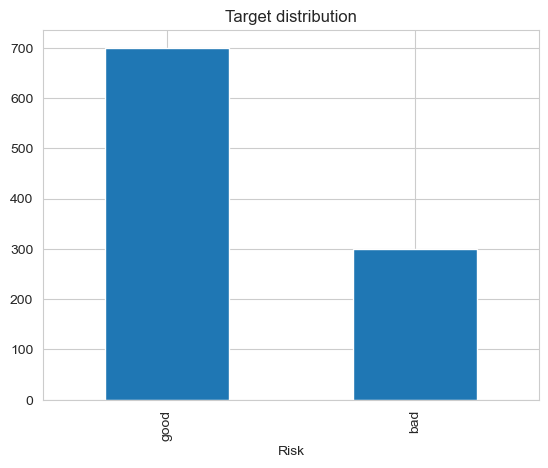

In [9]:
target_col = 'Risk' if 'Risk' in df.columns else df.columns[-1]
print(df[target_col].value_counts())
print(df[target_col].value_counts(normalize=True).round(3))

df[target_col].value_counts().plot(kind='bar', title='Target distribution')
plt.show()

# EDA on Relationships

Risk                bad   good
Checking account              
little            0.493  0.507
moderate          0.390  0.610
none              0.117  0.883
rich              0.222  0.778


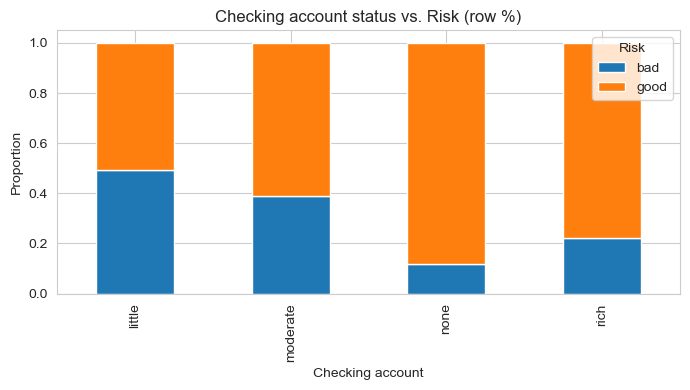

In [10]:
ct = pd.crosstab(df['Checking account'], df['Risk'], normalize='index').round(3)
print(ct)

ct.plot(kind='bar', stacked=True, figsize=(7,4), title='Checking account status vs. Risk (row %)')
plt.ylabel('Proportion')
plt.legend(title='Risk')
plt.tight_layout()
plt.show()

Risk               bad   good
Saving accounts              
little           0.360  0.640
moderate         0.330  0.670
none             0.175  0.825
quite rich       0.175  0.825
rich             0.125  0.875


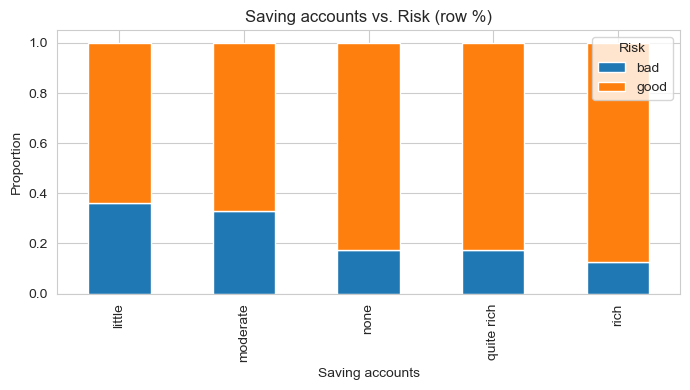

In [11]:
ct = pd.crosstab(df['Saving accounts'], df['Risk'], normalize='index').round(3)
print(ct)

ct.plot(kind='bar', stacked=True, figsize=(7,4), title='Saving accounts vs. Risk (row %)')
plt.ylabel('Proportion')
plt.legend(title='Risk')
plt.tight_layout()
plt.show()

Risk                   bad   good
Purpose                          
vacation/others      0.417  0.583
education            0.390  0.610
repairs              0.364  0.636
business             0.351  0.649
domestic appliances  0.333  0.667
furniture/equipment  0.320  0.680
car                  0.315  0.685
radio/TV             0.221  0.779


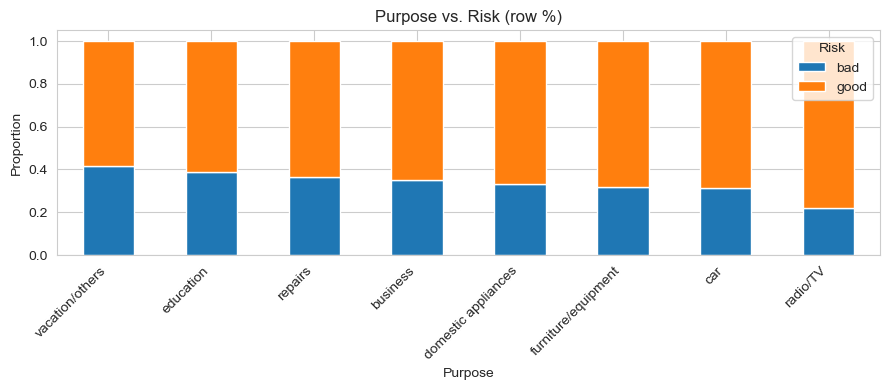

In [12]:
ct = pd.crosstab(df['Purpose'], df['Risk'], normalize='index').round(3).sort_values('bad', ascending=False)
print(ct)

ct.plot(kind='bar', stacked=True, figsize=(9,4), title='Purpose vs. Risk (row %)')
plt.ylabel('Proportion')
plt.legend(title='Risk')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
for col in ['Housing', 'Job', 'Sex']:
    ct = pd.crosstab(df[col], df['Risk'], normalize='index').round(3)
    print(f'--- {col} ---')
    print(ct, '\n')

--- Housing ---
Risk       bad   good
Housing              
free     0.407  0.593
own      0.261  0.739
rent     0.391  0.609 

--- Job ---
Risk    bad   good
Job               
0     0.318  0.682
1     0.280  0.720
2     0.295  0.705
3     0.345  0.655 

--- Sex ---
Risk      bad   good
Sex                 
female  0.352  0.648
male    0.277  0.723 



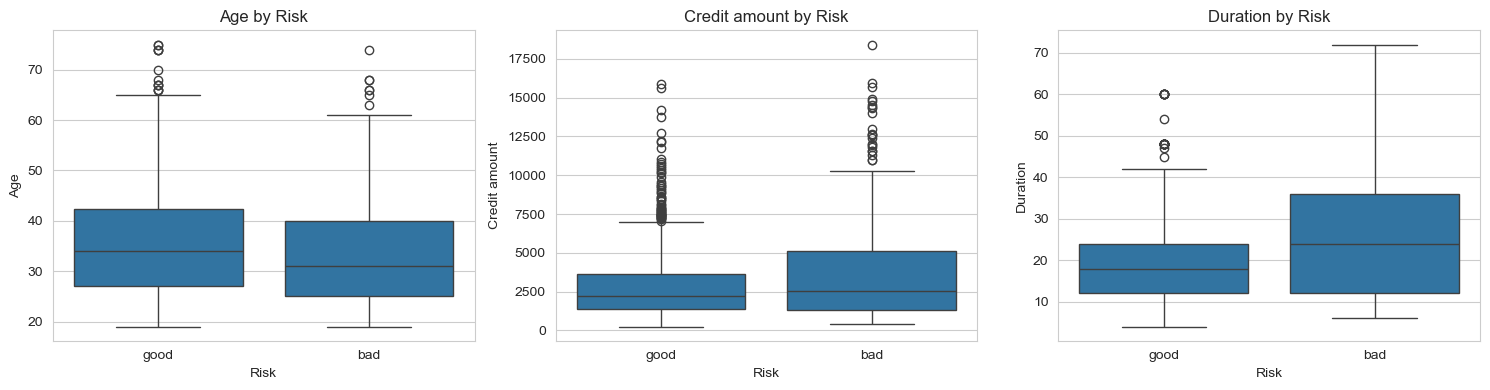

In [14]:
numeric_cols = ['Age', 'Credit amount', 'Duration']

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(5*len(numeric_cols), 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x='Risk', y=col, ax=ax)
    ax.set_title(f'{col} by Risk')
plt.tight_layout()
plt.show()

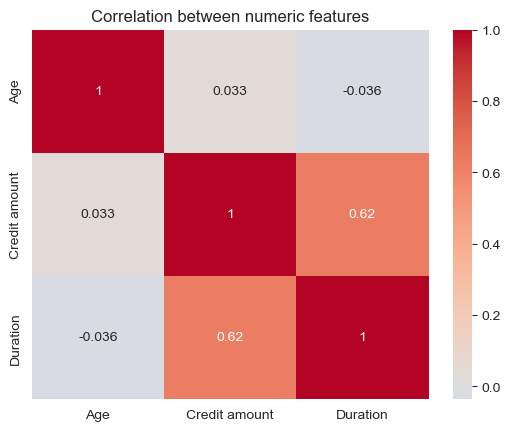

In [15]:
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation between numeric features')
plt.show()

# Feature Engineering

In [16]:
df['Risk_binary'] = df['Risk'].map({'good': 0, 'bad': 1})
df['Risk_binary'].value_counts()

Risk_binary
0    700
1    300
Name: count, dtype: int64

In [17]:
categorical_cols = ['Sex', 'Housing', 'Purpose', 'Saving accounts', 'Checking account']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.head()

,Age,Job,Credit amount,Duration,Risk,Risk_binary,Sex_male,Housing_own,Housing_rent,Purpose_car,...,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Saving accounts_moderate,Saving accounts_none,Saving accounts_quite rich,Saving accounts_rich,Checking account_moderate,Checking account_none,Checking account_rich
0,67,2,1169,6,good,0,True,True,False,False,...,True,False,False,False,True,False,False,False,False,False
1,22,2,5951,48,bad,1,False,True,False,False,...,True,False,False,False,False,False,False,True,False,False
2,49,1,2096,12,good,0,True,True,False,False,...,False,False,False,False,False,False,False,False,True,False
3,45,2,7882,42,good,0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,53,2,4870,24,bad,1,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [18]:
df_encoded['monthly_burden'] = df_encoded['Credit amount'] / df_encoded['Duration']
df_encoded[['Credit amount', 'Duration', 'monthly_burden']].describe()

,Credit amount,Duration,monthly_burden
count,1000.000000,1000.000000,1000.000000
mean,3271.258000,20.903000,167.687020
std,2822.736876,12.058814,153.490959
min,250.000000,4.000000,24.055556
25%,1365.500000,12.000000,89.600000
50%,2319.500000,18.000000,130.333333
75%,3972.250000,24.000000,206.183333
max,18424.000000,72.000000,2482.666667


In [19]:
bins = [18, 25, 35, 45, 60, 100]
labels = ['18-25', '26-35', '36-45', '46-60', '60+']
df_encoded['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Quick check: does bad-risk rate vary meaningfully by age group?
pd.crosstab(df_encoded['age_group'], df['Risk'], normalize='index').round(3)

Risk,bad,good
age_group,,
18-25,0.421,0.579
26-35,0.296,0.704
36-45,0.243,0.757
46-60,0.262,0.738
60+,0.222,0.778


In [20]:
 df_encoded = pd.get_dummies(df_encoded, columns=['age_group'], drop_first=True)

In [21]:
print(f'Shape: {df_encoded.shape}')
print(f'Missing values: {df_encoded.isnull().sum().sum()}')
df_encoded.dtypes

Shape: (1000, 28)
Missing values: 0


Age                              int64
Job                              int64
Credit amount                    int64
Duration                         int64
Risk                            object
Risk_binary                      int64
Sex_male                          bool
Housing_own                       bool
Housing_rent                      bool
Purpose_car                       bool
Purpose_domestic appliances       bool
Purpose_education                 bool
Purpose_furniture/equipment       bool
Purpose_radio/TV                  bool
Purpose_repairs                   bool
Purpose_vacation/others           bool
Saving accounts_moderate          bool
Saving accounts_none              bool
Saving accounts_quite rich        bool
Saving accounts_rich              bool
Checking account_moderate         bool
Checking account_none             bool
Checking account_rich             bool
monthly_burden                 float64
age_group_26-35                   bool
age_group_36-45          

In [22]:
# Drop the original text columns now that we have encoded versions
df_model = df_encoded.drop(columns=['Risk'])
df_model.to_csv('german_credit_model_ready.csv', index=False)
print('Saved: german_credit_model_ready.csv')

Saved: german_credit_model_ready.csv


# Handle Imbalance & Build Models

In [23]:
df = pd.read_csv('german_credit_model_ready.csv')

X = df.drop(columns=['Risk_binary'])
y = df['Risk_binary']

print(f'Features: {X.shape[1]}, Rows: {X.shape[0]}')
print(y.value_counts(normalize=True).round(3))

Features: 26, Rows: 1000
Risk_binary
0    0.7
1    0.3
Name: proportion, dtype: float64


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')

Train: 700 rows | Test: 300 rows


In [25]:
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

print('--- Baseline (no imbalance handling) ---')
print(classification_report(y_test, y_pred_baseline, target_names=['good', 'bad']))

--- Baseline (no imbalance handling) ---
              precision    recall  f1-score   support

        good       0.77      0.89      0.83       210
         bad       0.60      0.39      0.47        90

    accuracy                           0.74       300
   macro avg       0.69      0.64      0.65       300
weighted avg       0.72      0.74      0.72       300



D:\conda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [26]:
logreg_balanced = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg_balanced.fit(X_train, y_train)
y_pred_lr = logreg_balanced.predict(X_test)

print('--- Logistic Regression (class_weight=balanced) ---')
print(classification_report(y_test, y_pred_lr, target_names=['good', 'bad']))

--- Logistic Regression (class_weight=balanced) ---
              precision    recall  f1-score   support

        good       0.84      0.68      0.75       210
         bad       0.48      0.69      0.57        90

    accuracy                           0.68       300
   macro avg       0.66      0.68      0.66       300
weighted avg       0.73      0.68      0.70       300



D:\conda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [27]:
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('--- Random Forest (class_weight=balanced) ---')
print(classification_report(y_test, y_pred_rf, target_names=['good', 'bad']))

--- Random Forest (class_weight=balanced) ---
              precision    recall  f1-score   support

        good       0.78      0.94      0.85       210
         bad       0.73      0.39      0.51        90

    accuracy                           0.77       300
   macro avg       0.76      0.66      0.68       300
weighted avg       0.77      0.77      0.75       300



In [28]:
models = {
    'Baseline (no fix)': (baseline, y_pred_baseline),
    'Logistic (balanced)': (logreg_balanced, y_pred_lr),
    'Random Forest (balanced)': (rf, y_pred_rf),
}

rows = []
for name, (model, preds) in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    report = classification_report(y_test, preds, target_names=['good', 'bad'], output_dict=True)
    rows.append({
        'model': name,
        'recall_bad': round(report['bad']['recall'], 3),
        'precision_bad': round(report['bad']['precision'], 3),
        'f1_bad': round(report['bad']['f1-score'], 3),
        'roc_auc': round(roc_auc_score(y_test, proba), 3),
    })

pd.DataFrame(rows)

,model,recall_bad,precision_bad,f1_bad,roc_auc
0,Baseline (no fix),0.389,0.603,0.473,0.739
1,Logistic (balanced),0.689,0.481,0.566,0.740
2,Random Forest (balanced),0.389,0.729,0.507,0.758


In [29]:
y_proba_rf = rf.predict_proba(X_test)[:, 1]

for threshold in [0.5, 0.4, 0.35, 0.3, 0.25]:
    preds_at_threshold = (y_proba_rf >= threshold).astype(int)
    print(f'Threshold {threshold}: '
          f'recall={recall_score(y_test, preds_at_threshold):.3f}, '
          f'precision={precision_score(y_test, preds_at_threshold):.3f}, '
          f'f1={f1_score(y_test, preds_at_threshold):.3f}')

Threshold 0.5: recall=0.400, precision=0.706, f1=0.511
Threshold 0.4: recall=0.533, precision=0.565, f1=0.549
Threshold 0.35: recall=0.622, precision=0.549, f1=0.583
Threshold 0.3: recall=0.678, precision=0.459, f1=0.547
Threshold 0.25: recall=0.767, precision=0.429, f1=0.550


# SHAP Explainability

In [31]:
import shap

In [33]:
df = pd.read_csv('german_credit_model_ready.csv')
X = df.drop(columns=['Risk_binary'])
y = df['Risk_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

In [34]:
y_proba = rf.predict_proba(X_test)[:, 1]
y_pred_final = (y_proba >= 0.35).astype(int)

print(classification_report(y_test, y_pred_final, target_names=['good', 'bad']))

              precision    recall  f1-score   support

        good       0.83      0.78      0.80       210
         bad       0.55      0.62      0.58        90

    accuracy                           0.73       300
   macro avg       0.69      0.70      0.69       300
weighted avg       0.74      0.73      0.74       300



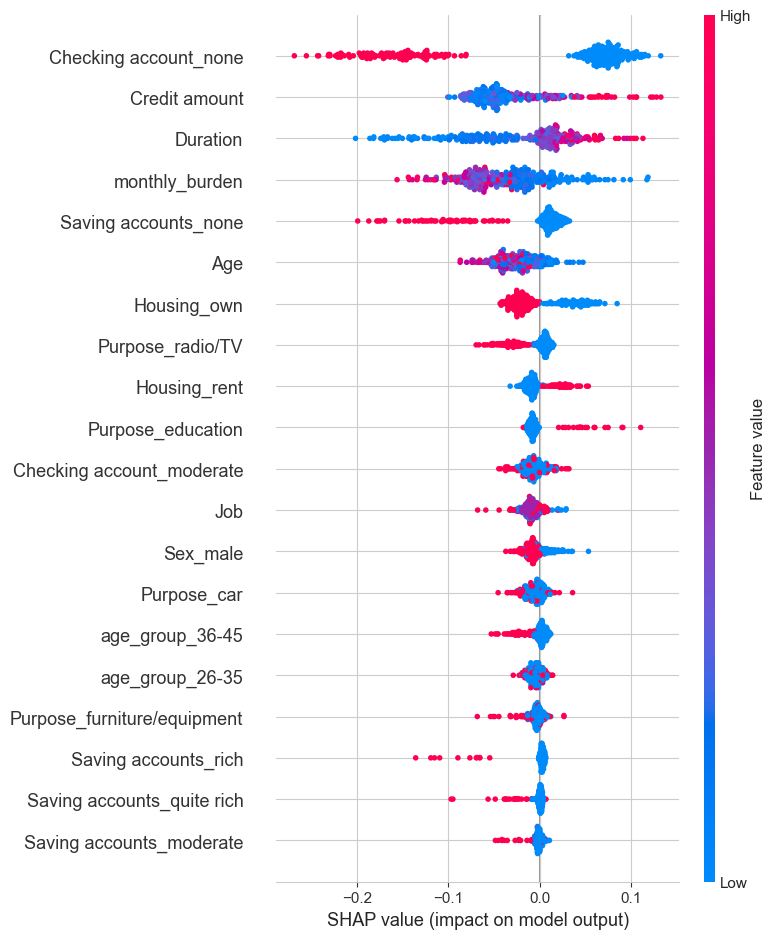

In [35]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Handle different SHAP output shapes across versions
if isinstance(shap_values, list):
    shap_values_bad = shap_values[1]
elif shap_values.ndim == 3:
    shap_values_bad = shap_values[:, :, 1]
else:
    shap_values_bad = shap_values

shap.summary_plot(shap_values_bad, X_test, show=True)

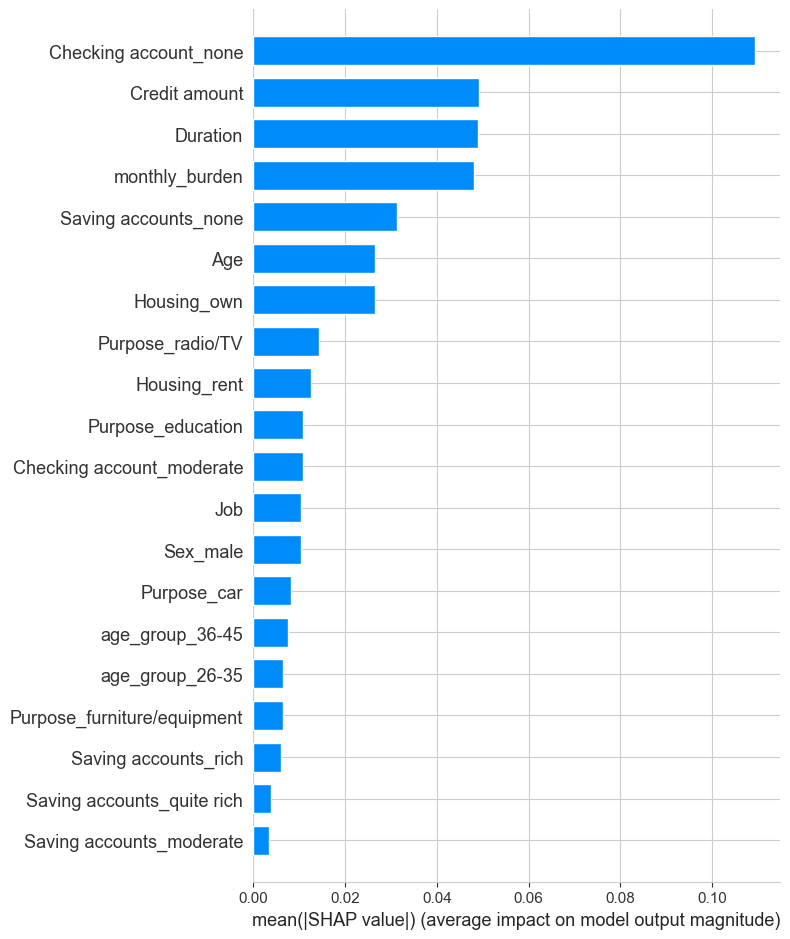

In [36]:
shap.summary_plot(shap_values_bad, X_test, plot_type='bar', show=True)

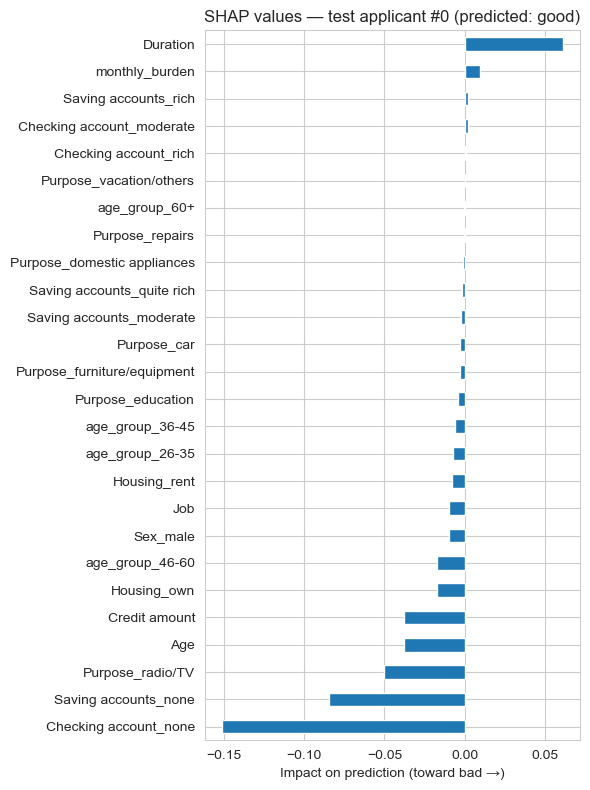

In [37]:
idx = 0
predicted_label = 'bad' if y_pred_final[idx] == 1 else 'good'

individual_shap = pd.Series(shap_values_bad[idx], index=X_test.columns).sort_values()
individual_shap.plot(
    kind='barh', figsize=(6, 8),
    title=f'SHAP values — test applicant #{idx} (predicted: {predicted_label})'
)
plt.xlabel('Impact on prediction (toward bad →)')
plt.tight_layout()
plt.show()

In [38]:
importance = pd.Series(np.abs(shap_values_bad).mean(axis=0), index=X_test.columns)
importance.sort_values(ascending=False).head(10)

Checking account_none    0.109295
Credit amount            0.049135
Duration                 0.049023
monthly_burden           0.048117
Saving accounts_none     0.031261
Age                      0.026649
Housing_own              0.026451
Purpose_radio/TV         0.014449
Housing_rent             0.012506
Purpose_education        0.010886
dtype: float64